# Notebook 14 — MAnet | EfficientNet-B4 | Trained on COVID-QU-Ex
Cross-dataset generalization study: train on COVID-QU-Ex, evaluate on BOTH datasets.

## 0. Config — ONLY CHANGE THESE 3 LINES PER NOTEBOOK

In [1]:
ARCH         = "MAnet"
ENCODER      = "efficientnet-b4"
TRAIN_DS     = "COVIDQU"

RUN_ID = f"manet_{ENCODER.replace('-','').replace('_','')}_{TRAIN_DS}"
print(f"RUN_ID: {RUN_ID}")

RUN_ID: manet_efficientnetb4_COVIDQU


## 1. Install Dependencies

In [2]:

!pip install -q segmentation-models-pytorch albumentations kaggle kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.4 MB/s eta 0:00:00


## 2. Imports

In [3]:
import os, json, random, time
from pathlib import Path

import numpy as np
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 3. Hyper-parameters

In [4]:
IMG_SIZE     = 256
BATCH_SIZE   = 128
EPOCHS       = 50
LR           = 5.83e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 7
NUM_WORKERS  = 8

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

## 4. Google Drive Mount

In [5]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

DRIVE_DIR = Path("/content/drive/MyDrive/LungSeg_UNetPP") / RUN_ID
DRIVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Drive dir: {DRIVE_DIR}")

Mounted at /content/drive
Drive dir: /content/drive/MyDrive/LungSeg_UNetPP/manet_efficientnetb4_COVIDQU


## 5. Kaggle Authentication + Download Datasets

In [6]:
from google.colab import files
import os, json

uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
creds = list(uploaded.values())[0]
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(creds)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

creds_dict = json.loads(creds)
os.environ["KAGGLE_USERNAME"]    = creds_dict["username"]
os.environ["KAGGLE_KEY"]         = creds_dict["key"]
os.environ["KAGGLE_CONFIG_DIR"]  = "/root/.kaggle"
print(f"Authenticated as: {creds_dict['username']} ✓")

import kagglehub

print("\nFetching COVID-QU-Ex augmented dataset...")
COVIDQU_BASE = Path(kagglehub.dataset_download("elhamidyabderahman/covidqu-augmented"))
print(f"COVID-QU-Ex path : {COVIDQU_BASE}")

print("\nFetching Chest X-Ray augmented dataset...")
CXR_BASE = Path(kagglehub.dataset_download("elhamidyabderahman/augmented-xray-variants-v1"))
print(f"CXR path         : {CXR_BASE}")

Saving kaggle.json to kaggle.json
Authenticated as: elhamidyabderahman ✓

Fetching COVID-QU-Ex augmented dataset...


100%|██████████| 12.4G/12.4G [05:22<00:00, 41.4MB/s]

Extracting files...


COVID-QU-Ex path : /root/.cache/kagglehub/datasets/elhamidyabderahman/covidqu-augmented/versions/1

Fetching Chest X-Ray augmented dataset...


100%|██████████| 2.78G/2.78G [01:16<00:00, 38.8MB/s]

Extracting files...


CXR path         : /root/.cache/kagglehub/datasets/elhamidyabderahman/augmented-xray-variants-v1/versions/2


## 6. Build File Pair Lists

In [7]:
def collect_covidqu_pairs(base: Path):
    pairs = []
    chunk_dirs = sorted(base.glob("lung_chunk*_of_22"))
    print(f"  Found {len(chunk_dirs)} lung chunk folders")
    for chunk in chunk_dirs:
        for split in ["Train", "Val", "Test"]:
            for cat in ["COVID-19", "Non-COVID", "Normal"]:
                img_dir  = chunk / "lung" / split / cat / "images"
                mask_dir = chunk / "lung" / split / cat / "masks"
                if not img_dir.exists():
                    continue
                for img_path in sorted(img_dir.glob("*.png")):
                    mask_path = mask_dir / (img_path.stem + "_mask.png")
                    if mask_path.exists():
                        pairs.append((str(img_path), str(mask_path)))
    return pairs


def collect_cxr_pairs(base: Path):
    img_dir  = base / "aug_cxray_data" / "images"
    mask_dir = base / "aug_cxray_data" / "masks"
    pairs = []
    for img_path in sorted(img_dir.glob("*.png")):
        mask_path = mask_dir / (img_path.stem + "_mask.png")
        if mask_path.exists():
            pairs.append((str(img_path), str(mask_path)))
    return pairs


print("Collecting COVID-QU-Ex pairs...")
covidqu_pairs = collect_covidqu_pairs(COVIDQU_BASE)
print(f"  Total COVID-QU-Ex pairs : {len(covidqu_pairs):,}")

print("Collecting CXR pairs...")
cxr_pairs = collect_cxr_pairs(CXR_BASE)
print(f"  Total CXR pairs         : {len(cxr_pairs):,}")

assert len(covidqu_pairs) > 0, "No COVID-QU-Ex pairs found!"
assert len(cxr_pairs)     > 0, "No CXR pairs found!"

  Found 22 lung chunk folders
  Total COVID-QU-Ex pairs : 169,600
  Total CXR pairs         : 40,071


## 7. Train / Val / Test Splits (80 / 10 / 10, seed=42)

In [8]:
def make_splits(pairs, seed=42):
    train, tmp = train_test_split(pairs, test_size=0.20, random_state=seed)
    val, test  = train_test_split(tmp,   test_size=0.50, random_state=seed)
    return train, val, test

covidqu_train, covidqu_val, covidqu_test = make_splits(covidqu_pairs)
cxr_train,     cxr_val,     cxr_test     = make_splits(cxr_pairs)

# Subsample COVIDQU train to 50% (~67,960 pairs)
random.seed(42)
COVIDQU_SUBSAMPLE = 67960
if len(covidqu_train) > COVIDQU_SUBSAMPLE:
    covidqu_train = random.sample(covidqu_train, COVIDQU_SUBSAMPLE)

print(f"COVID-QU-Ex — train: {len(covidqu_train):,}  val: {len(covidqu_val):,}  test: {len(covidqu_test):,}")
print(f"CXR         — train: {len(cxr_train):,}  val: {len(cxr_val):,}  test: {len(cxr_test):,}")

COVID-QU-Ex — train: 67,960  val: 16,960  test: 16,960
CXR         — train: 32,056  val: 4,007  test: 4,008


## 8. Dataset & DataLoaders

In [9]:
class SegDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs     = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img  = cv2.imread(img_path)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img.shape[:2] != (IMG_SIZE, IMG_SIZE):
            img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        if mask.shape[:2] != (IMG_SIZE, IMG_SIZE):
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"]

        return img, mask.unsqueeze(0)


train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

if TRAIN_DS == "COVIDQU":
    tr_pairs, va_pairs = covidqu_train, covidqu_val
    print(f"Training on COVID-QU-Ex: {len(tr_pairs):,} train | {len(va_pairs):,} val")
else:
    tr_pairs, va_pairs = cxr_train, cxr_val
    print(f"Training on CXR: {len(tr_pairs):,} train | {len(va_pairs):,} val")

train_loader = DataLoader(SegDataset(tr_pairs, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True,
                          prefetch_factor=2)
val_loader   = DataLoader(SegDataset(va_pairs, val_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True,
                          prefetch_factor=2)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Training on COVID-QU-Ex: 67,960 train | 16,960 val
Train batches: 531  |  Val batches: 133


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 9. Model
Note: MAnet does not support decoder_attention_type

In [10]:
model = smp.MAnet(
    encoder_name    = ENCODER,
    encoder_weights = "imagenet",
    in_channels     = 3,
    classes         = 1,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : {ARCH} + {ENCODER}")
print(f"Parameters : {total_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Model      : MAnet + efficientnet-b4
Parameters : 25,627,453


## 10. Loss, Optimizer, Scheduler

In [11]:
bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode="binary")

def combined_loss(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6)

## 11. Metrics

In [12]:
def compute_metrics(pred_logits, targets, threshold=0.5):
    preds = (torch.sigmoid(pred_logits) > threshold).float()
    tp = (preds * targets).sum()
    fp = (preds * (1 - targets)).sum()
    fn = ((1 - preds) * targets).sum()
    tn = ((1 - preds) * (1 - targets)).sum()

    dice  = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    iou   = tp / (tp + fp + fn + 1e-8)
    pixel = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    return dice.item(), iou.item(), pixel.item()

## 12. Resume Support (timeout-safe)

In [13]:
CKPT_PATH    = DRIVE_DIR / f"{RUN_ID}_best.pth"
HISTORY_PATH = DRIVE_DIR / f"{RUN_ID}_history.json"

history = {"train_loss": [], "val_loss": [], "val_dice": [],
           "val_iou": [], "val_pixel_acc": [], "lr": []}

start_epoch   = 0
best_val_dice = 0.0
no_improve    = 0

if CKPT_PATH.exists():
    print(f"Resuming from {CKPT_PATH}")
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    best_val_dice = ckpt["best_val_dice"]
    start_epoch   = ckpt["epoch"] + 1
    no_improve    = ckpt.get("no_improve", 0)
    if HISTORY_PATH.exists():
        with open(HISTORY_PATH) as f:
            history = json.load(f)
    print(f"  Resumed at epoch {start_epoch}, best dice {best_val_dice:.4f}")
else:
    print("Starting fresh training run.")

Starting fresh training run.


## 13. Training Loop

In [14]:
def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


def validate(loader):
    model.eval()
    total_loss, total_dice, total_iou, total_pixel = 0., 0., 0., 0.
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss  = combined_loss(preds, masks)
            d, i, p = compute_metrics(preds, masks)
            total_loss  += loss.item() * imgs.size(0)
            total_dice  += d * imgs.size(0)
            total_iou   += i * imgs.size(0)
            total_pixel += p * imgs.size(0)
    n = len(loader.dataset)
    return total_loss/n, total_dice/n, total_iou/n, total_pixel/n


print(f"\nTraining {RUN_ID} for {EPOCHS} epochs (starting at {start_epoch})\n")
print(f"{'Ep':>4} {'TrLoss':>8} {'VLoss':>8} {'VDice':>7} "
      f"{'VIoU':>7} {'VPixAcc':>8} {'LR':>9} {'Time':>7}")
print("-" * 70)

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()

    tr_loss             = train_one_epoch(train_loader)
    vl_loss, vd, vi, vp = validate(val_loader)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["val_dice"].append(vd)
    history["val_iou"].append(vi)
    history["val_pixel_acc"].append(vp)
    history["lr"].append(current_lr)

    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f)

    improved = vd > best_val_dice
    if improved:
        best_val_dice = vd
        no_improve    = 0
        torch.save({
            "epoch"          : epoch,
            "model_state"    : model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_dice"  : best_val_dice,
            "no_improve"     : no_improve,
        }, CKPT_PATH)
        flag = " ✓"
    else:
        no_improve += 1
        flag = ""

    elapsed = time.time() - t0
    print(f"{epoch+1:>4} {tr_loss:>8.4f} {vl_loss:>8.4f} {vd:>7.4f} "
          f"{vi:>7.4f} {vp:>8.4f} {current_lr:>9.2e} {elapsed:>6.0f}s{flag}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs).")
        break

print(f"\nBest Val Dice: {best_val_dice:.4f}")


Training manet_efficientnetb4_COVIDQU for 50 epochs (starting at 0)

  Ep   TrLoss    VLoss   VDice    VIoU  VPixAcc        LR    Time
----------------------------------------------------------------------
   1   0.0690   0.0328  0.9744  0.9501   0.9881  5.82e-04    234s ✓
   2   0.0304   0.0284  0.9771  0.9552   0.9893  5.81e-04    232s ✓
   3   0.0285   0.0273  0.9778  0.9565   0.9895  5.78e-04    232s ✓
   4   0.0271   0.0262  0.9784  0.9578   0.9899  5.74e-04    232s ✓
   5   0.0266   0.0259  0.9788  0.9584   0.9900  5.69e-04    232s ✓
   6   0.0268   0.0256  0.9789  0.9588   0.9901  5.63e-04    232s ✓
   7   0.0255   0.0254  0.9791  0.9590   0.9901  5.55e-04    231s ✓
   8   0.0249   0.0250  0.9794  0.9597   0.9904  5.47e-04    232s ✓
   9   0.0246   0.0247  0.9796  0.9600   0.9904  5.38e-04    232s ✓
  10   0.0241   0.0243  0.9799  0.9607   0.9906  5.27e-04    232s ✓
  11   0.0235   0.0249  0.9794  0.9597   0.9903  5.16e-04    231s
  12   0.0232   0.0235  0.9806  0.9619   0.9909

## 14. Cross-Dataset Evaluation

In [15]:
print(f"\nLoading best checkpoint: {CKPT_PATH}")
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()


def evaluate_dataset(pairs, name):
    loader = DataLoader(SegDataset(pairs, val_tf),
                        batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True,
                        persistent_workers=True,
                        prefetch_factor=2)
    total_loss, total_dice, total_iou, total_pixel = 0., 0., 0., 0.
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss  = combined_loss(preds, masks)
            d, i, p = compute_metrics(preds, masks)
            total_loss  += loss.item() * imgs.size(0)
            total_dice  += d * imgs.size(0)
            total_iou   += i * imgs.size(0)
            total_pixel += p * imgs.size(0)
    n = len(loader.dataset)
    results = {
        "dataset"    : name,
        "n_samples"  : n,
        "loss"       : round(total_loss  / n, 4),
        "dice"       : round(total_dice  / n, 4),
        "iou"        : round(total_iou   / n, 4),
        "pixel_acc"  : round(total_pixel / n, 4),
    }
    print(f"\n{'─'*50}")
    print(f"Eval on {name} ({n:,} samples)")
    for k, v in results.items():
        if k not in ("dataset", "n_samples"):
            print(f"  {k:12s}: {v:.4f}")
    return results


if TRAIN_DS == "COVIDQU":
    in_dist_results  = evaluate_dataset(covidqu_test, "COVID-QU-Ex (in-dist)")
    ood_results      = evaluate_dataset(cxr_test,     "CXR (out-of-dist)")
else:
    in_dist_results  = evaluate_dataset(cxr_test,     "CXR (in-dist)")
    ood_results      = evaluate_dataset(covidqu_test,  "COVID-QU-Ex (out-of-dist)")


Loading best checkpoint: /content/drive/MyDrive/LungSeg_UNetPP/manet_efficientnetb4_COVIDQU/manet_efficientnetb4_COVIDQU_best.pth

──────────────────────────────────────────────────
Eval on COVID-QU-Ex (in-dist) (16,960 samples)
  loss        : 0.0188
  dice        : 0.9848
  iou         : 0.9701
  pixel_acc   : 0.9929

──────────────────────────────────────────────────
Eval on CXR (out-of-dist) (4,008 samples)
  loss        : 0.1070
  dice        : 0.9556
  iou         : 0.9150
  pixel_acc   : 0.9777


## 15. Save Summary JSON

In [16]:
summary = {
    "run_id"         : RUN_ID,
    "arch"           : ARCH,
    "encoder"        : ENCODER,
    "train_dataset"  : TRAIN_DS,
    "img_size"       : IMG_SIZE,
    "batch_size"     : BATCH_SIZE,
    "epochs_trained" : len(history["val_dice"]),
    "best_val_dice"  : round(best_val_dice, 4),
    "in_dist_eval"   : in_dist_results,
    "ood_eval"       : ood_results,
}

SUMMARY_PATH = DRIVE_DIR / f"{RUN_ID}_summary.json"
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nSummary saved → {SUMMARY_PATH}")
print(json.dumps(summary, indent=2))


Summary saved → /content/drive/MyDrive/LungSeg_UNetPP/manet_efficientnetb4_COVIDQU/manet_efficientnetb4_COVIDQU_summary.json
{
  "run_id": "manet_efficientnetb4_COVIDQU",
  "arch": "MAnet",
  "encoder": "efficientnet-b4",
  "train_dataset": "COVIDQU",
  "img_size": 256,
  "batch_size": 128,
  "epochs_trained": 50,
  "best_val_dice": 0.9847,
  "in_dist_eval": {
    "dataset": "COVID-QU-Ex (in-dist)",
    "n_samples": 16960,
    "loss": 0.0188,
    "dice": 0.9848,
    "iou": 0.9701,
    "pixel_acc": 0.9929
  },
  "ood_eval": {
    "dataset": "CXR (out-of-dist)",
    "n_samples": 4008,
    "loss": 0.107,
    "dice": 0.9556,
    "iou": 0.915,
    "pixel_acc": 0.9777
  }
}


## 16. Training Curves

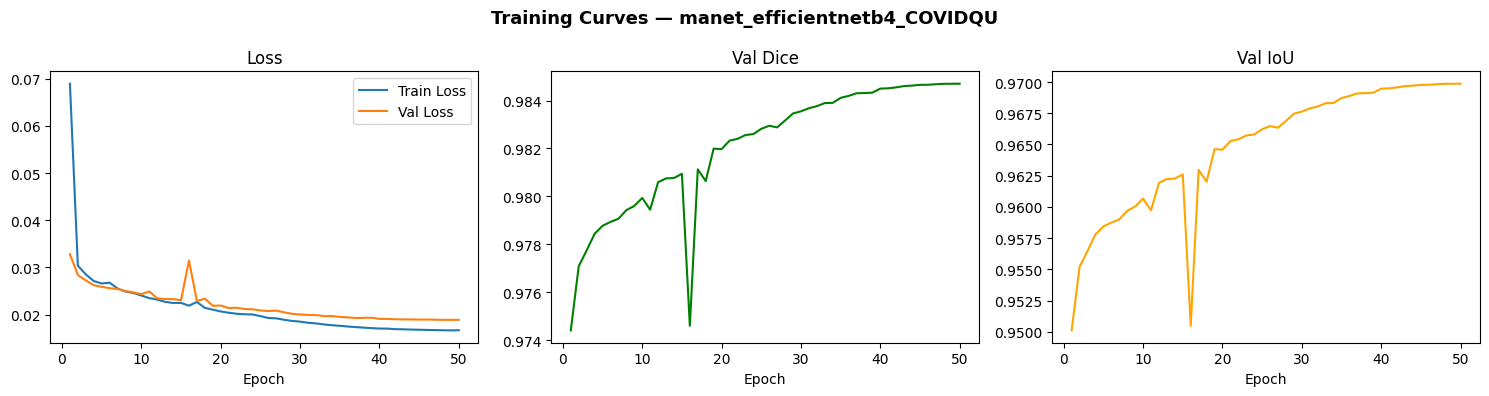

Curves saved → /content/drive/MyDrive/LungSeg_UNetPP/manet_efficientnetb4_COVIDQU/manet_efficientnetb4_COVIDQU_curves.png


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, len(history["val_dice"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["val_dice"], color="green")
axes[1].set_title("Val Dice"); axes[1].set_xlabel("Epoch")

axes[2].plot(epochs_range, history["val_iou"], color="orange")
axes[2].set_title("Val IoU"); axes[2].set_xlabel("Epoch")

plt.suptitle(f"Training Curves — {RUN_ID}", fontsize=13, fontweight="bold")
plt.tight_layout()
CURVE_PATH = DRIVE_DIR / f"{RUN_ID}_curves.png"
plt.savefig(CURVE_PATH, dpi=100, bbox_inches="tight")
plt.show()
print(f"Curves saved → {CURVE_PATH}")

## 17. OOD Visualisation

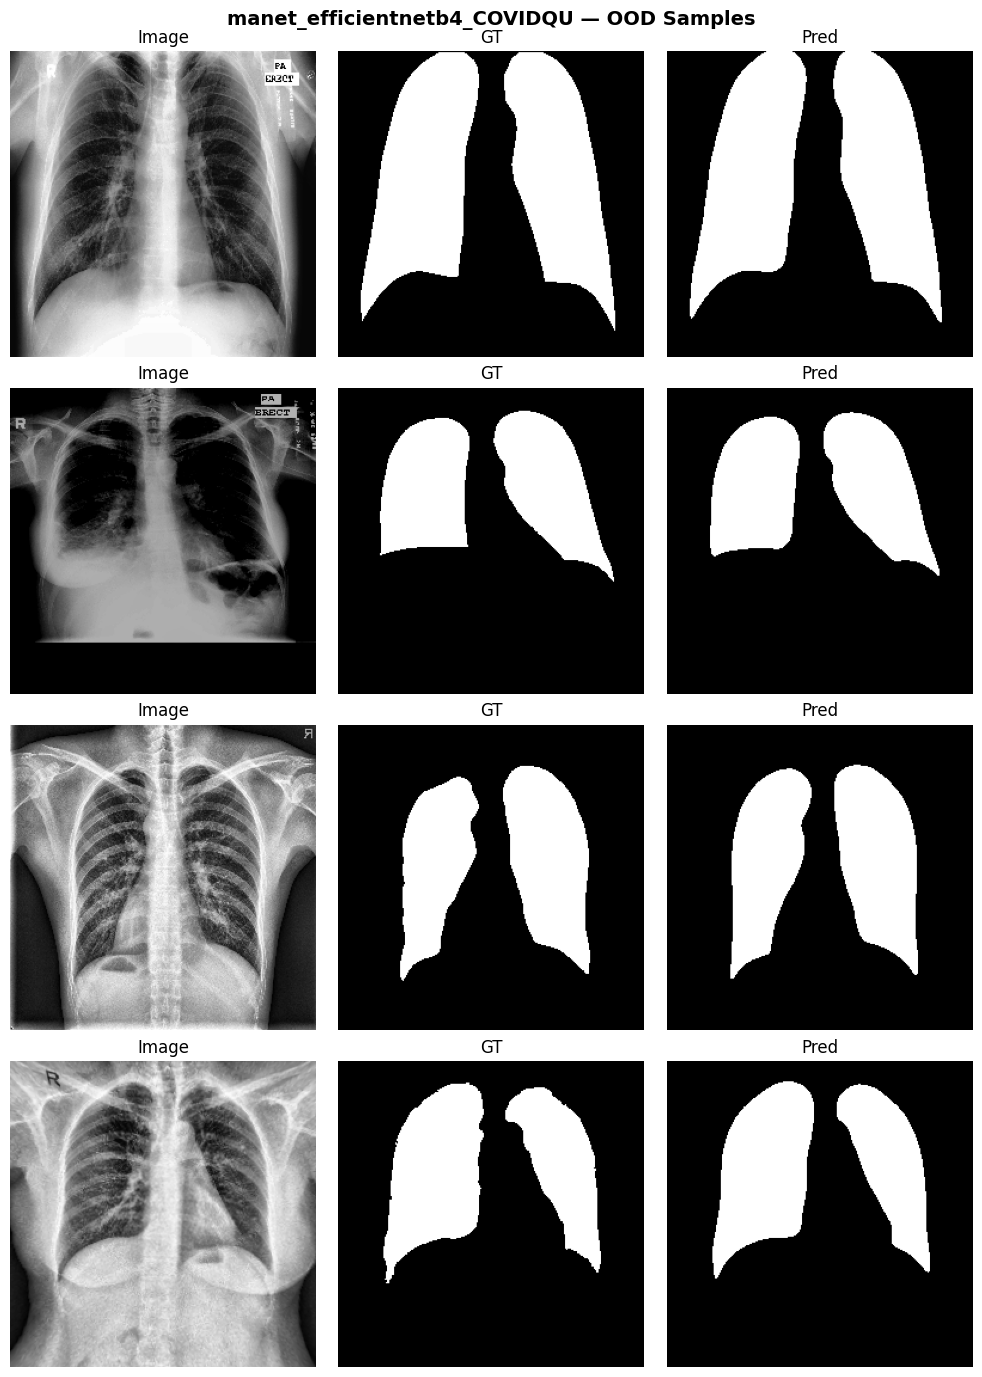

Visualisation saved → /content/drive/MyDrive/LungSeg_UNetPP/manet_efficientnetb4_COVIDQU/manet_efficientnetb4_COVIDQU_ood_samples.png


In [18]:
sample_pairs = (cxr_test if TRAIN_DS == "COVIDQU" else covidqu_test)[:4]

fig, axes = plt.subplots(4, 3, figsize=(10, 14))
model.eval()

for row, (img_path, mask_path) in enumerate(sample_pairs):
    img_bgr   = cv2.imread(img_path)
    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mask_gt   = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    aug       = val_tf(image=img_rgb, mask=(mask_gt > 127).astype(np.float32))
    inp       = aug["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_mask = (torch.sigmoid(model(inp)) > 0.5).squeeze().cpu().numpy()

    axes[row, 0].imshow(img_rgb);               axes[row, 0].set_title("Image");  axes[row, 0].axis("off")
    axes[row, 1].imshow(mask_gt,  cmap="gray");  axes[row, 1].set_title("GT");    axes[row, 1].axis("off")
    axes[row, 2].imshow(pred_mask, cmap="gray"); axes[row, 2].set_title("Pred");  axes[row, 2].axis("off")

plt.suptitle(f"{RUN_ID} — OOD Samples", fontsize=14, fontweight="bold")
plt.tight_layout()
VIS_PATH = DRIVE_DIR / f"{RUN_ID}_ood_samples.png"
plt.savefig(VIS_PATH, dpi=100, bbox_inches="tight")
plt.show()
print(f"Visualisation saved → {VIS_PATH}")